In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#reading the dataset
df=pd.read_csv("Facebook_Marketplace_data.csv")

In [ ]:
#displaying the dataset
df.head(10)

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
0,1,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN
1,2,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN
2,3,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN
3,4,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0,NaN,NaN,NaN,NaN
4,5,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0,NaN,NaN,NaN,NaN
5,6,photo,4/18/2018 2:14,217,6,0,211,5,1,0,0,0,NaN,NaN,NaN,NaN
6,7,video,4/18/2018 0:24,503,614,72,418,70,10,2,0,3,NaN,NaN,NaN,NaN
7,8,video,4/17/2018 7:42,295,453,53,260,32,1,1,0,1,NaN,NaN,NaN,NaN
8,9,photo,4/17/2018 3:33,203,1,0,198,5,0,0,0,0,NaN,NaN,NaN,NaN
9,10,photo,4/11/2018 4:53,170,9,1,167,3,0,0,0,0,NaN,NaN,NaN,NaN




---


Question 1.
How does the time of upload (`status_published`)  affect the `num_reaction`?


---



In [ ]:
#displaying the concerned column
print(df["status_published"])

0        4/22/2018 6:00
1       4/21/2018 22:45
2        4/21/2018 6:17
3        4/21/2018 2:29
4        4/18/2018 3:22
             ...       
7045     9/24/2016 2:58
7046    9/23/2016 11:19
7047    9/21/2016 23:03
7048     9/20/2016 0:43
7049    9/10/2016 10:30
Name: status_published, Length: 7050, dtype: object


In [ ]:
#extracting only the time
df["status_published"] = pd.to_datetime(df["status_published"])
df["publish_time"] = df["status_published"].dt.hour
print(df["publish_time"])

0        6
1       22
2        6
3        2
4        3
        ..
7045     2
7046    11
7047    23
7048     0
7049    10
Name: publish_time, Length: 7050, dtype: int32


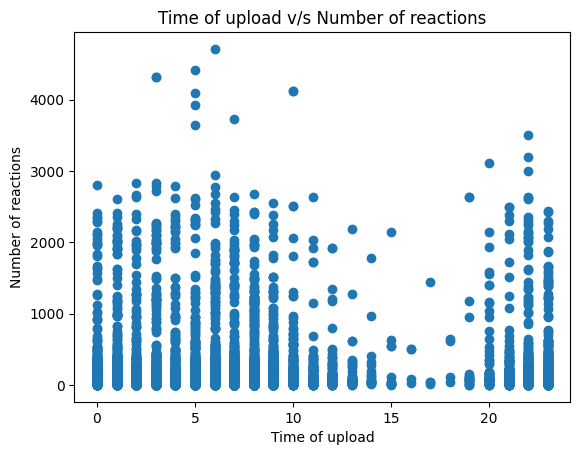

In [ ]:
#plotting a scatter plot to infer the effect of time on the number of reactions
plt.scatter(df["publish_time"], df["num_reactions"])
plt.title("Time of upload v/s Number of reactions")
plt.xlabel("Time of upload")
plt.ylabel("Number of reactions")
plt.show()



---


Question 2. Is there a correlation between the number of reactions (num_reactions) and other engagement metrics such as comments (num_comments) and shares (num_shares)? If so, what is the strength and direction of this correlation?


---



In [ ]:
#checking the presence of NaN values
a=df["num_comments"].isnull().sum()
b=df["num_reactions"].isnull().sum()
c=df["num_shares"].isnull().sum()

print(a,b,c)

0 0 0


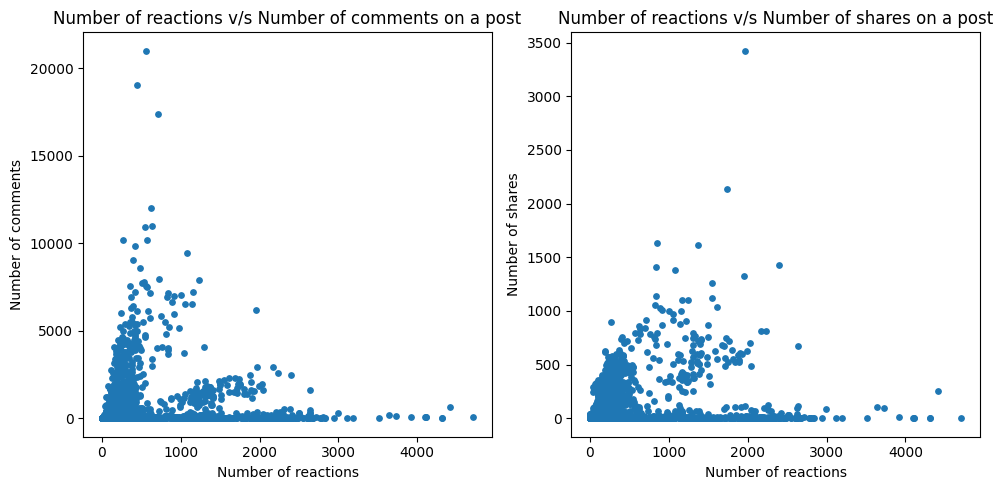

In [ ]:
#scatter plot:
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.scatter(df["num_reactions"], df["num_comments"], s=15)
plt.title("Number of reactions v/s Number of comments on a post")
plt.xlabel("Number of reactions")
plt.ylabel("Number of comments")
plt.subplot(1,2,2)
plt.scatter(df["num_reactions"], df["num_shares"], s=15)
plt.title("Number of reactions v/s Number of shares on a post")
plt.xlabel("Number of reactions")
plt.ylabel("Number of shares")
plt.tight_layout()
plt.show()

In [ ]:
#correlation matrix:
correlation_matrix=df[["num_reactions", "num_comments", "num_shares"]].corr()
print(correlation_matrix)

               num_reactions  num_comments  num_shares
num_reactions       1.000000      0.150843    0.250723
num_comments        0.150843      1.000000    0.640637
num_shares          0.250723      0.640637    1.000000


<Axes: >

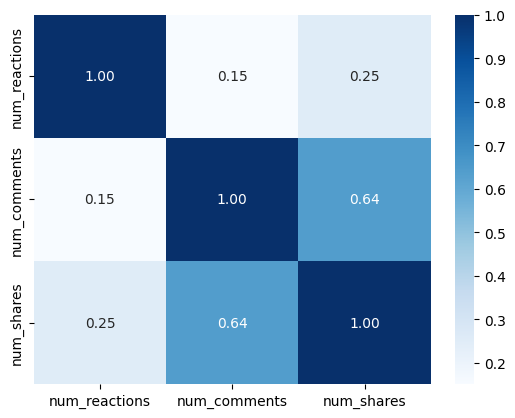

In [ ]:
#visual representation of correlation matrix:

import seaborn as sns
sns.heatmap(correlation_matrix, annot=True, cmap="Blues", fmt=".2f")




---


Question 3. Use the columns status_type, num_reactions, num_comments, num_shares, num_likes, num_loves, num_wows, num_hahas, num_sads, and num_angrys to train a K-Means clustering model on the Facebook Live Sellers dataset.

Question 4. Use the elbow method to find the optimum number of clusters.

---



In [ ]:
#converting data of column status_type to numeric data for the application of Kmeans clusterig model
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(df["status_type"])
print(y)

[3 1 3 ... 1 1 1]


In [ ]:
from sklearn.cluster import KMeans

In [ ]:
#creating dataframe of the concerned columns
x=df.drop(["status_published", "status_id", "publish_time", "Column1", "Column2", "Column3", "Column4"], axis=1)
x["status_type"]=y
print(x)

      status_type  num_reactions  num_comments  num_shares  num_likes  \
0               3            529           512         262        432   
1               1            150             0           0        150   
2               3            227           236          57        204   
3               1            111             0           0        111   
4               1            213             0           0        204   
...           ...            ...           ...         ...        ...   
7045            1             89             0           0         89   
7046            1             16             0           0         14   
7047            1              2             0           0          1   
7048            1            351            12          22        349   
7049            1             17             0           0         17   

      num_loves  num_wows  num_hahas  num_sads  num_angrys  
0            92         3          1         1           0  
1

In [ ]:
#elbow method
wcss=[]
for i in range(1,11):
  kmeans=KMeans(n_clusters=i, init="k-means++", random_state=42)
  kmeans.fit(x)
  wcss.append(kmeans.inertia_)

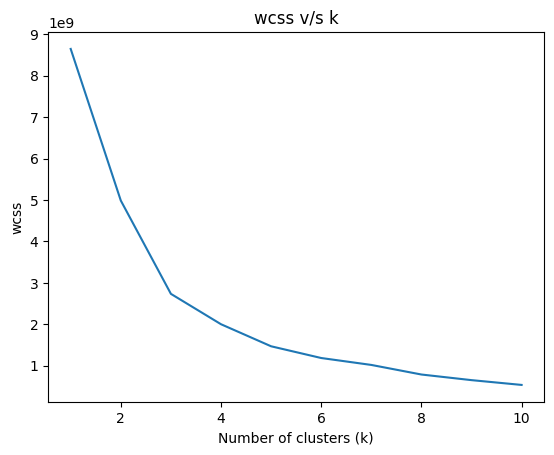

In [ ]:
plt.plot(range(1,11), wcss)
plt.xlabel("Number of clusters (k)")
plt.ylabel("wcss")
plt.title("wcss v/s k")
plt.show()

In [ ]:
#fixing the number of clusters in the model
kmeans=KMeans(n_clusters=3, init="k-means++", random_state=42)
y_kmeans=kmeans.fit_predict(x)

In [ ]:
#plotting the clusters (but didn't work as the below code is for one or two dimensional dataset)
plt.scatter(x[y_kmeans==0,0], x[y_kmeans==0,1], x[y_kmeans==0,2], x[y_kmeans==0,3], x[y_kmeans==0,4], x[y_kmeans==0,5], x[y_kmeans==0,6], x[y_kmeans==0,7], x[y_kmeans==0,8], x[y_kmeans==0,9], s=100, c="red", label="Cluster_1")
plt.scatter(x[y_kmeans==1,0], x[y_kmeans==1,1], x[y_kmeans==1,2], x[y_kmeans==1,3], x[y_kmeans==1,4], x[y_kmeans==1,5], x[y_kmeans==1,6], x[y_kmeans==1,7], x[y_kmeans==1,8], x[y_kmeans==1,9], s=100, c="blue", label="Cluster_2")
plt.scatter(x[y_kmeans==2,0], x[y_kmeans==2,1], x[y_kmeans==2,2], x[y_kmeans==2,3], x[y_kmeans==2,4], x[y_kmeans==2,5], x[y_kmeans==2,6], x[y_kmeans==2,7], x[y_kmeans==2,8], x[y_kmeans==2,9], s=100, c="green", label="Cluster_3")

plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], kmeans.cluster_centers_[:,2], kmeans.cluster_centers_[:,3], kmeans.cluster_centers_[:,4], kmeans.cluster_centers_[:,5], kmeans.cluster_centers_[:,6], kmeans.cluster_centers_[:,7], kmeans.cluster_centers_[:,8], kmeans.cluster_centers_[:,9], s=300, c="yellow", label="centroids")

InvalidIndexError: (array([ True,  True,  True, ...,  True,  True,  True]), 0)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


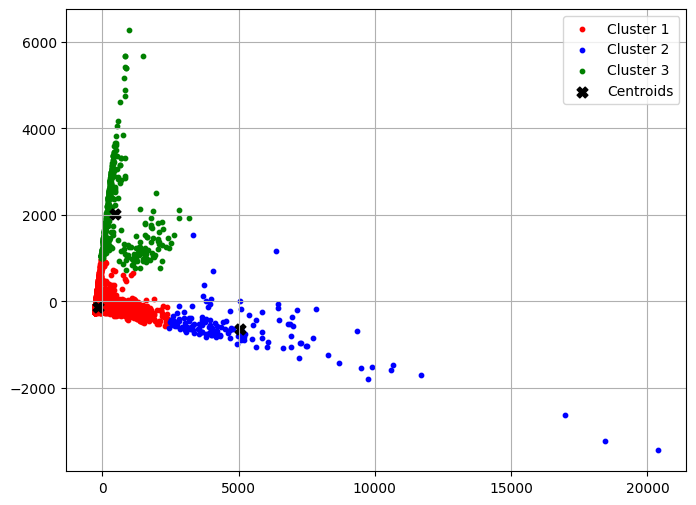

In [ ]:
#using PCA to reduce the dataset to two dimensions
from sklearn.decomposition import PCA

#Reduce to 2 dimensions for plotting
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)

#Recomputing cluster centers in reduced space
centroids_2d = pca.transform(kmeans.cluster_centers_)

#Plot clusters
plt.figure(figsize=(8, 6))
plt.scatter(x_pca[y_kmeans == 0, 0], x_pca[y_kmeans == 0, 1], s=10, c='red', label='Cluster 1')
plt.scatter(x_pca[y_kmeans == 1, 0], x_pca[y_kmeans == 1, 1], s=10, c='blue', label='Cluster 2')
plt.scatter(x_pca[y_kmeans == 2, 0], x_pca[y_kmeans == 2, 1], s=10, c='green', label='Cluster 3')

#Plot centroids
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1], s=60, c='black', label='Centroids', marker='X')


plt.legend()
plt.grid(True)
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


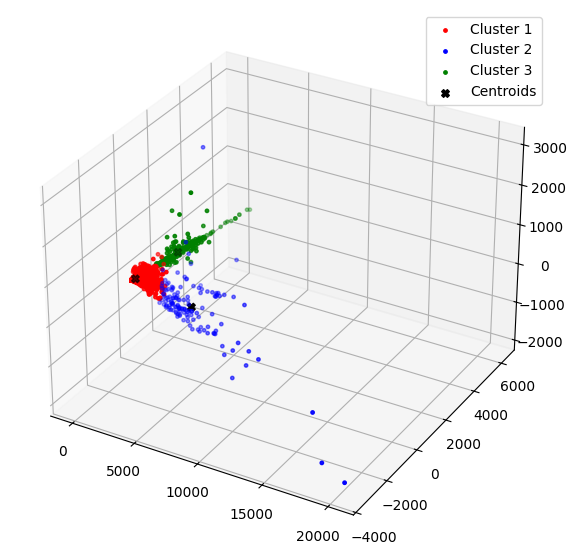

In [ ]:
#3d visualization
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# Step 1: Reduce to 3 principal components
pca = PCA(n_components=3)
x_pca_3d = pca.fit_transform(x)
centroids_3d = pca.transform(kmeans.cluster_centers_)

# Step 2: Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot each cluster
ax.scatter(x_pca_3d[y_kmeans == 0, 0], x_pca_3d[y_kmeans == 0, 1], x_pca_3d[y_kmeans == 0, 2],
           s=6, c='red', label='Cluster 1')
ax.scatter(x_pca_3d[y_kmeans == 1, 0], x_pca_3d[y_kmeans == 1, 1], x_pca_3d[y_kmeans == 1, 2],
           s=6, c='blue', label='Cluster 2')
ax.scatter(x_pca_3d[y_kmeans == 2, 0], x_pca_3d[y_kmeans == 2, 1], x_pca_3d[y_kmeans == 2, 2],
           s=6, c='green', label='Cluster 3')

# Plot centroids
ax.scatter(centroids_3d[:, 0], centroids_3d[:, 1], centroids_3d[:, 2],
           s=30, c='black', marker='X', label='Centroids')


ax.legend()
plt.show()




---

Question 5. What is the count of different types of posts in the dataset?


---



In [ ]:
#directly using inbuilt method
print(df["status_type"].value_counts())

status_type
photo     4288
video     2334
status     365
link        63
Name: count, dtype: int64


In [ ]:
df["status_type"].unique()

array(['video', 'photo', 'link', 'status'], dtype=object)

In [ ]:
#using a for loop
count={}
for value in df["status_type"]:
  if value in count:
    count[value]+=1
  else:
    count[value]=1

print(count)

{'video': 2334, 'photo': 4288, 'link': 63, 'status': 365}


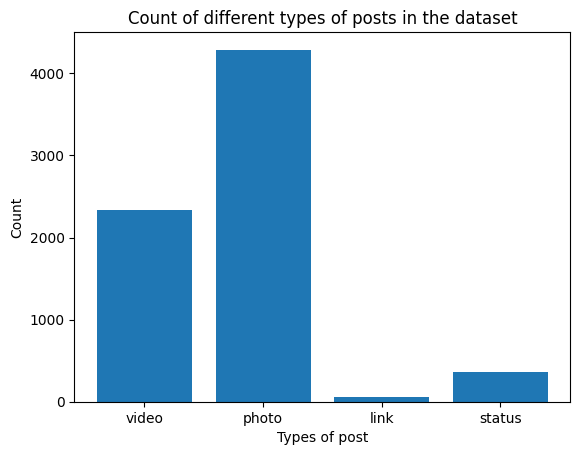

In [ ]:
#visual representation
plt.bar(count.keys(), count.values())
plt.title("Count of different types of posts in the dataset")
plt.xlabel("Types of post")
plt.ylabel("Count")
plt.show()



---

Question 6. What is the average value of num_reaction, num_comments, num_shares for each post type?


---



In [ ]:
#segregation and average
a=df.groupby("status_type")
print(a[["num_reactions", "num_comments", "num_shares"]].mean())

             num_reactions  num_comments  num_shares
status_type                                         
link            370.142857      5.698413    4.396825
photo           181.290345     15.993470    2.553871
status          438.783562     36.238356    2.558904
video           283.409597    642.478149  115.679949


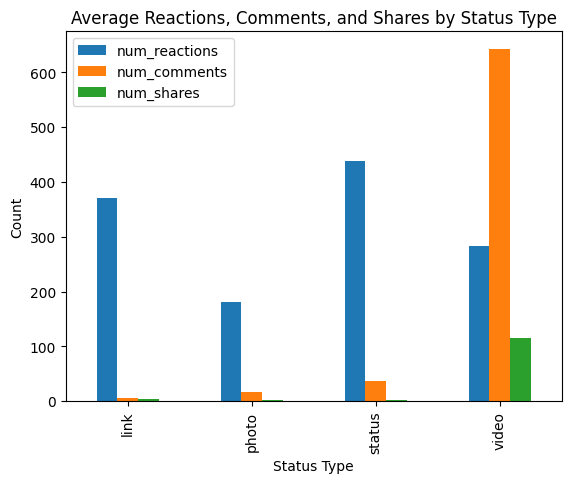

In [ ]:
#plotting
data = {
    'status_type': ['link', 'photo', 'status', 'video'],
    'num_reactions': [370.14, 181.29, 438.78, 283.41],
    'num_comments': [5.70, 15.99, 36.24, 642.48],
    'num_shares': [4.40, 2.55, 2.56, 115.68]
}

df = pd.DataFrame(data)
df.set_index('status_type', inplace=True)
df.plot(kind='bar')
plt.title('Average Reactions, Comments, and Shares by Status Type')
plt.ylabel('Count')
plt.xlabel('Status Type')
plt.show()